Nesse notebook são plotados os boxplots de algumas variáveis agregadas de acordo com os perfis.

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

Dictionary to update the name of the patterns from Portuguese to English:

In [2]:
update_prof = {'Episódico/Epidêmico':'Episodic/Epidemic', 'Epidêmico':'Epidemic', 'Episódico':'Episodic',
       'Transmissão Persistente':'Persistent Transmission', 'Sem transmissão': 'No Transmission', 
              'Sem transmissao': 'No Transmission'}

Load the csv with the population from IBGE:

In [3]:
pop = pd.read_csv('../Determinantes/Tabelas/poptcu2010-2022new.csv', sep = ',', usecols= ['CODMUN7', 'POP22', 'POP10'])
#pop['populacao'] = pop['populacao'].astype(float)
pop.columns = pop.columns.str.lower()
pop.head()

,codmun7,pop22,pop10
0,1100015,21495,24392.0
1,1100023,96833,90353.0
2,1100031,5363,6313.0
3,1100049,86895,78574.0
4,1100056,15890,17029.0


In [4]:
pop.isnull().sum()

codmun7    0
pop22      0
pop10      5
dtype: int64

In [5]:
pop.loc[pop.pop10 == 4568]

,codmun7,pop22,pop10
428,1718907,4656,4568.0
3947,4103008,4558,4568.0
4066,4110904,4481,4568.0
4274,4126355,5007,4568.0


In [6]:
pop.loc[pop.pop22 == 3747]

,codmun7,pop22,pop10
1142,2406155,3747,3582.0
2852,3152131,3747,3966.0
2926,3158607,3747,3860.0
4940,4315206,3747,4141.0


In [7]:
pop.pop10.value_counts()[pop.pop10.value_counts() >1]

pop10
4568.0     4
10276.0    4
5217.0     4
4656.0     4
6016.0     4
          ..
25774.0    2
4123.0     2
51651.0    2
27328.0    2
10214.0    2
Name: count, Length: 465, dtype: int64

In [8]:
pop.pop22.value_counts()[pop.pop22.value_counts() >1]

pop22
3747    4
5228    4
4841    4
4127    4
2946    4
       ..
3887    2
6327    2
6371    2
5331    2
7024    2
Name: count, Length: 450, dtype: int64

Dataframe with the patterns between 2010 and 2019:

In [9]:
df_10_19 = pd.read_csv('../Determinantes/clima/clima_agg_10_19.csv', index_col = 'Unnamed: 0')

df_10_19.loc[:, 'dengue_pattern'] = df_10_19.dengue_pattern.replace(update_prof)

df_10_19['period'] = '10_19'

df_10_19 = df_10_19.merge(pop[['codmun7', 'pop10']], left_on = 'geocodigo', right_on = 'codmun7').drop('codmun7', axis = 1).rename(columns = {'pop10': 'pop'})

df_10_19.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,pop
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,Episodic/Epidemic,10_19,19377.0
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,Episodic/Epidemic,10_19,17424.0
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,Epidemic,10_19,214006.0
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,Episodic/Epidemic,10_19,44322.0
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,Episodic,10_19,14230.0


In [10]:
df_10_19.dengue_pattern.unique()

array(['Episodic/Epidemic', 'Epidemic', 'Episodic',
       'Persistent Transmission', 'No Transmission'], dtype=object)

Porcentagem de valores relacionados com cada perfil:

In [11]:
df_10_19.dengue_pattern.value_counts()/df_10_19.shape[0]

dengue_pattern
Episodic/Epidemic          0.537522
Episodic                   0.319569
Epidemic                   0.103052
No Transmission            0.037343
Persistent Transmission    0.002513
Name: count, dtype: float64

Dataframe with the patterns between 2020 and 2022:

In [12]:
df_20_22 = pd.read_csv('../Determinantes/clima/clima_agg_20_22.csv', index_col = 'Unnamed: 0')

df_20_22 = df_20_22.merge(pop[['codmun7', 'pop22']], left_on = 'geocodigo', right_on = 'codmun7').drop('codmun7', axis = 1).rename(columns = {'pop22': 'pop'})

df_20_22.loc[:, 'dengue_pattern'] = df_20_22.dengue_pattern.replace(update_prof)

df_20_22['period'] = '20_22'

df_20_22.dengue_pattern.value_counts()/df_20_22.shape[0]

dengue_pattern
Episodic/Epidemic          0.484919
Episodic                   0.300718
Epidemic                   0.163555
No Transmission            0.043806
Persistent Transmission    0.007002
Name: count, dtype: float64

Concatenate both dataframes to generate the boxplots

In [13]:
df = pd.concat([df_10_19, df_20_22])

df.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,pop
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,Episodic/Epidemic,10_19,19377.0
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,Episodic/Epidemic,10_19,17424.0
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,Epidemic,10_19,214006.0
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,Episodic/Epidemic,10_19,44322.0
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,Episodic,10_19,14230.0


Set the order the patterns will appear in the plots: 

In [14]:
prof_order = ['No Transmission', 'Episodic', 'Episodic/Epidemic', 'Epidemic', 
       'Persistent Transmission']


Variáveis climáticas:

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/3127701684.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/3127701684.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/3127701684.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


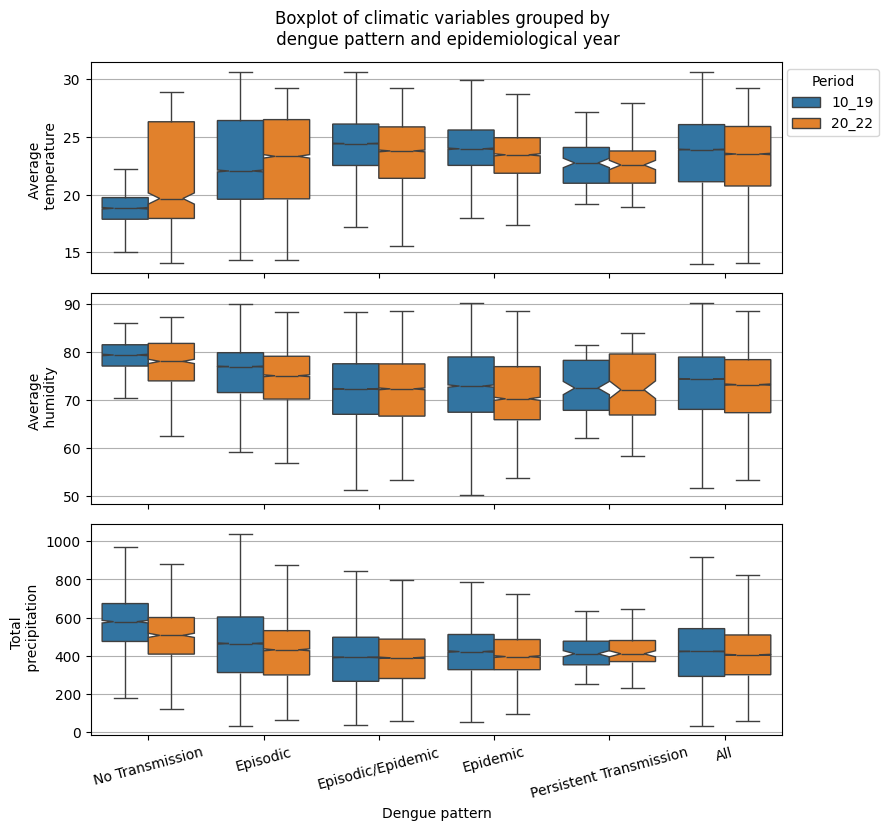

In [15]:
fig, ax = plt.subplots(3,1, figsize = (9, 8),  sharex = True)

sns.boxplot(x='dengue_pattern', y='temp_med', data=df, showfliers = False, order = prof_order, hue = 'period', ax=ax[0],
           notch = True)

sns.boxplot(y='temp_med', data=df, showfliers = False, hue = 'period', ax=ax[0],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[0].set_ylabel('Average \n temperature')

ax[0].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='umid_med', data=df, showfliers = False,order = prof_order,  hue = 'period',ax=ax[1],notch = True, legend = False)

sns.boxplot(y='umid_med', data=df, showfliers = False, hue = 'period', ax=ax[1],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[1].set_ylabel('Average \n humidity')

ax[1].grid(True, axis='y')


sns.boxplot(x='dengue_pattern', y='precip_tot', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[2],notch = True, legend = False)

sns.boxplot(y='precip_tot', data=df, showfliers = False,  hue = 'period', ax=ax[2],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[2].set_ylabel('Total \n precipitation')

ax[2].grid(True, axis='y')


plt.suptitle('Boxplot of climatic variables grouped by \n dengue pattern and epidemiological year')

for ax_ in [ax[0], ax[1], ax[2]]:

    ax_.set_xticklabels(list(prof_order) + ['All'])
    ax_.set_xlabel('Dengue pattern')

ax[0].legend(title = 'Period', loc='upper right', bbox_to_anchor = (1.15, 1))


plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_clima.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Variáveis de acordo com o somatório do dia:

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/1130342346.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/1130342346.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/1130342346.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/1130342346.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_

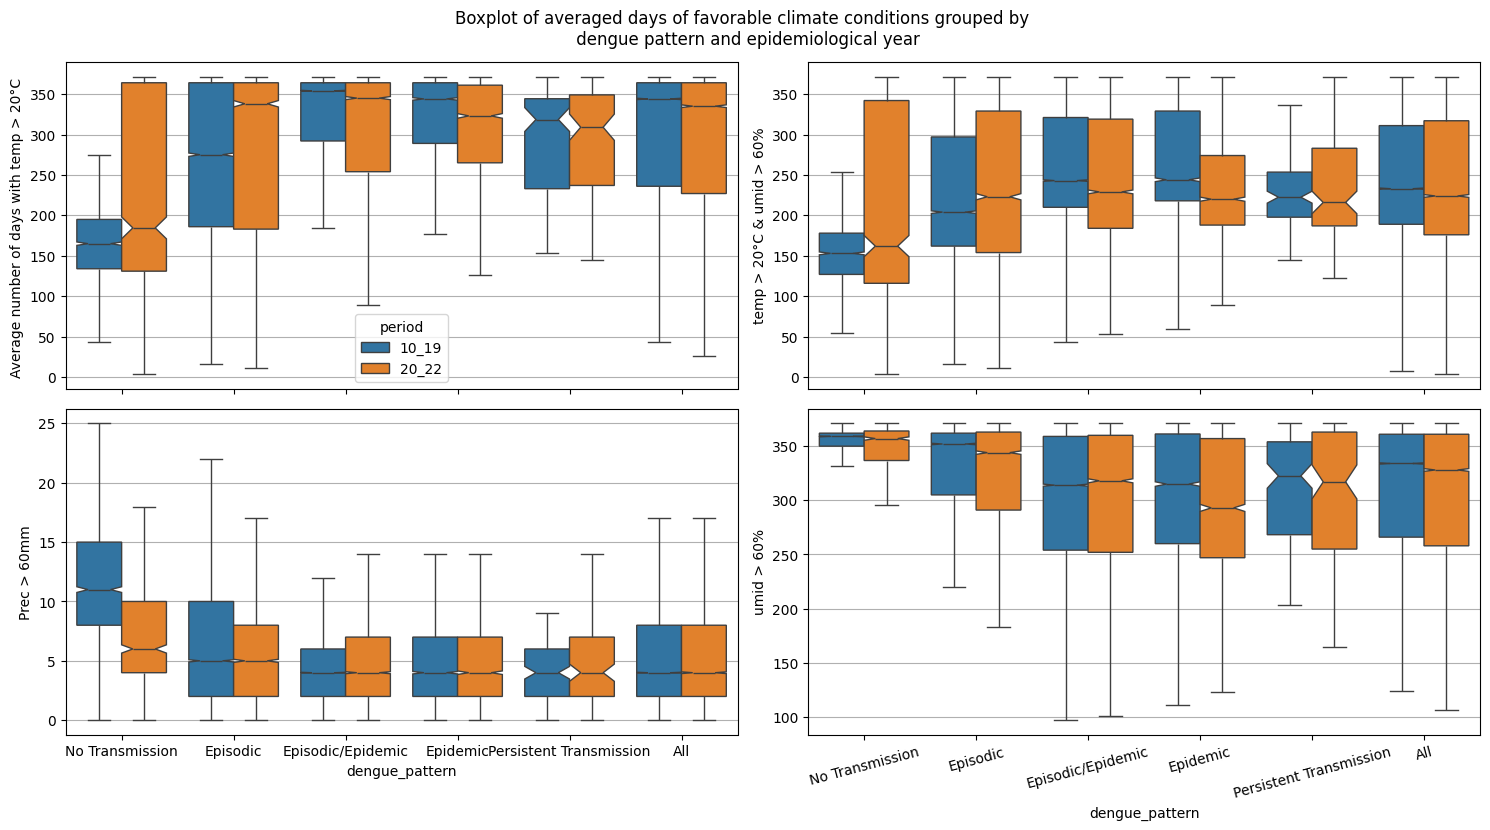

In [16]:
fig, ax = plt.subplots(2,2, figsize = (15, 8),  sharex = True)

sns.boxplot(x='dengue_pattern', y='thr_temp', data=df, showfliers = False, order = prof_order, hue = 'period', ax=ax[0,0],
           notch = True)

sns.boxplot(y='thr_temp', data=df, showfliers = False, hue = 'period', ax=ax[0,0],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[0,0].set_ylabel('Average number of days with temp > 20°C ')


sns.boxplot(x='dengue_pattern', y='thr_temp_umid', data=df, showfliers = False,order = prof_order,  hue = 'period',ax=ax[0, 1],
            legend = False, notch = True)

sns.boxplot(y='thr_temp_umid', data=df, showfliers = False, hue = 'period', ax=ax[0,1],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[0, 1].set_ylabel('temp > 20°C & umid > 60%')


sns.boxplot(x='dengue_pattern', y='thr_prec', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[1,0],
            legend = False, notch = True)

sns.boxplot(y='thr_prec', data=df, showfliers = False, hue = 'period', ax=ax[1,0],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[1,0].set_ylabel('Prec > 60mm')

sns.boxplot(x='dengue_pattern', y='thr_umid', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[1,1],
            legend = False, notch = True)

sns.boxplot(y='thr_umid', data=df, showfliers = False, hue = 'period', ax=ax[1,1],
           notch = True, palette = ['tab:blue','tab:orange'], legend = False)

ax[1,1].set_ylabel('umid > 60%')

for ax_ in ax.ravel():
    ax_.grid(True, axis='y')
    ax_.set_xticklabels(list(prof_order) + ['All'])
    
plt.suptitle('Boxplot of averaged days of favorable climate conditions grouped by \n dengue pattern and epidemiological year')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_thr_clima.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Get the data to make the plot manually: 

In [17]:
df_pop = df[['geocodigo', 'dengue_pattern', 'period','pop']]

df_pop = df_pop.dropna()
df_pop.head()

,geocodigo,dengue_pattern,period,pop
0,2700102,Episodic/Epidemic,10_19,19377.0
1,2700201,Episodic/Epidemic,10_19,17424.0
2,2700300,Epidemic,10_19,214006.0
3,2700409,Episodic/Epidemic,10_19,44322.0
4,2700508,Episodic,10_19,14230.0


In [18]:
df_pop.dengue_pattern.unique()

array(['Episodic/Epidemic', 'Epidemic', 'Episodic',
       'Persistent Transmission', 'No Transmission'], dtype=object)

In [19]:
df_pop.isnull().sum()

geocodigo         0
dengue_pattern    0
period            0
pop               0
dtype: int64

In [20]:
df_pop.loc[df_pop['pop'].isna() == True]

,geocodigo,dengue_pattern,period,pop


## Boxplot da população: 

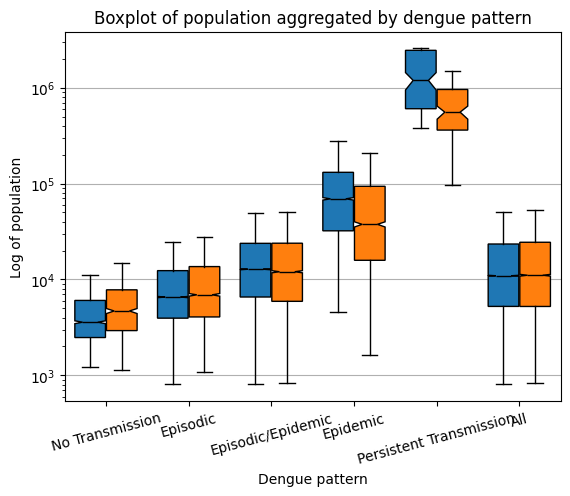

In [21]:
data1 = np.random.normal(100, 10, 200)
data2 = np.random.normal(90, 15, 200)
data3 = np.random.normal(95, 10, 200)
data4 = np.random.normal(85, 15, 200)


data_pop = [df_pop.loc[ (df_pop.dengue_pattern == 'No Transmission') & (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[ (df_pop.dengue_pattern == 'No Transmission') & (df_pop.period == '20_22')]['pop'].values,
            df_pop.loc[ (df_pop.dengue_pattern == 'Episodic') & (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[ (df_pop.dengue_pattern == 'Episodic') & (df_pop.period == '20_22')]['pop'].values,
            df_pop.loc[ (df_pop.dengue_pattern == 'Episodic/Epidemic') & (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[ (df_pop.dengue_pattern == 'Episodic/Epidemic') & (df_pop.period == '20_22')]['pop'].values,
            df_pop.loc[ (df_pop.dengue_pattern == 'Epidemic') & (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[ (df_pop.dengue_pattern == 'Epidemic') & (df_pop.period == '20_22')]['pop'].values,
            df_pop.loc[ (df_pop.dengue_pattern == 'Persistent Transmission') & (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[ (df_pop.dengue_pattern == 'Persistent Transmission') & (df_pop.period == '20_22')]['pop'].values,
             df_pop.loc[  (df_pop.period == '10_19')]['pop'].values,
           df_pop.loc[(df_pop.period == '20_22')]['pop'].values,
            
           ]


# Create a figure
fig, ax = plt.subplots()

box = ax.boxplot(data_pop, positions=[1, 1.62, 
                                      2.62, 3.24,
                                      4.24, 4.86,
                                     5.86, 6.48,
                                     7.48, 8.1,
                                     9.1, 9.72], widths=0.6, notch = True, showfliers = False, patch_artist = True)


colors = ['tab:blue', 'tab:orange', 
          'tab:blue', 'tab:orange',
         'tab:blue', 'tab:orange',
         'tab:blue', 'tab:orange',
         'tab:blue', 'tab:orange',
         'tab:blue', 'tab:orange']

# Set the box colors (background fill)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set the median line color to black
for median in box['medians']:
    median.set_color('black')


ax.set_xlabel('Dengue pattern')
ax.set_ylabel('Log of population')

tick_positions = [1.31, 2.93, 4.55, 6.17, 7.79, 9.41]

plt.xticks(tick_positions, prof_order+ ['All'])
plt.yscale('log')

ax.grid(True, axis='y')

ax.set_title('Boxplot of population aggregated by dengue pattern')

plt.xticks(rotation=15) 

plt.savefig('../figures/boxplot_pop.png',  dpi = 300, bbox_inches = 'tight')

plt.show()

Boxplot of other variables: 

In [22]:
df_perfis_10_19 = pd.read_csv('../Dengue/dengue_pattern_10_19.csv', sep = ';', usecols = ['muni_code', 'dengue_pattern'])

df_perfis_10_19.head()

,muni_code,dengue_pattern
0,1100015,Episódico/Epidêmico
1,1100023,Epidêmico
2,1100031,Episódico/Epidêmico
3,1100049,Epidêmico
4,1100056,Episódico/Epidêmico


In [23]:
df_perfis_10_19.isnull().sum()

muni_code         0
dengue_pattern    0
dtype: int64

In [24]:
df_perfis_20_22 = pd.read_csv('../Dengue/dengue_pattern_20_22.csv', sep = ';', usecols = ['muni_code', 'dengue_pattern'])
df_perfis_20_22 = df_perfis_20_22.dropna()
df_perfis_20_22['muni_code'] = df_perfis_20_22['muni_code'].astype(int)
df_perfis_20_22.head()

,muni_code,dengue_pattern
0,1100015,Epidêmico
2,1100023,Epidêmico
3,1100031,Episódico/Epidêmico
4,1100049,Epidêmico
5,1100056,Episódico/Epidêmico


In [25]:
df_perfis_20_22.isnull().sum()

muni_code         0
dengue_pattern    0
dtype: int64

In [26]:
df_det = pd.read_csv('../Determinantes/Tabelas/banco_determinantes_fim.csv',encoding='latin-1', sep = ';')

df_det_10_19 = df_det.merge(df_perfis_10_19, left_on='muni_code', right_on = 'muni_code')

df_det_10_19.loc[:, 'dengue_pattern'] = df_det_10_19.dengue_pattern.replace(update_prof)

for col in ['altitude', 'prop_esgot', 'prop_abast', 'prop_residuo']:
    df_det_10_19[col] = df_det_10_19[col].str.replace(',', '.').astype(float)

df_det_10_19['period'] = '10_19'

df_det_10_19.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,prop_esgot,prop_abast,prop_residuo,dengue_pattern,period
0,1100015,Alta Floresta D'oeste,11,RO,não metropolitana,amazonia,246.08,Am,21558,2.24,93.68,56.86,Episodic/Epidemic,10_19
1,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,8.91,98.57,85.14,Epidemic,10_19
2,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,21.01,95.49,49.77,Episodic/Epidemic,10_19
3,1100049,Cacoal,11,RO,metropolitana,amazonia,229.95,Am,92202,54.03,98.16,78.94,Epidemic,10_19
4,1100056,Cerejeiras,11,RO,não metropolitana,amazonia,192.22,Am,15237,16.73,98.62,78.35,Episodic/Epidemic,10_19


In [27]:
df_det_20_22 = df_det.merge(df_perfis_20_22, left_on='muni_code', right_on = 'muni_code')

df_det_20_22.loc[:, 'dengue_pattern'] = df_det_20_22.dengue_pattern.replace(update_prof)

for col in ['altitude', 'prop_esgot', 'prop_abast', 'prop_residuo']:
    df_det_20_22[col] = df_det_20_22[col].str.replace(',', '.').astype(float)

df_det_20_22['period'] = '20_22'

df_det_20_22.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,prop_esgot,prop_abast,prop_residuo,dengue_pattern,period
0,1100015,Alta Floresta D'oeste,11,RO,não metropolitana,amazonia,246.08,Am,21558,2.24,93.68,56.86,Epidemic,20_22
1,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,8.91,98.57,85.14,Epidemic,20_22
2,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,8.91,98.57,85.14,Epidemic,20_22
3,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,21.01,95.49,49.77,Episodic/Epidemic,20_22
4,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,21.01,95.49,49.77,Episodic/Epidemic,20_22


In [28]:
df_det_ = pd.concat([df_det_10_19, df_det_20_22])

df_det_.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,prop_esgot,prop_abast,prop_residuo,dengue_pattern,period
0,1100015,Alta Floresta D'oeste,11,RO,não metropolitana,amazonia,246.08,Am,21558,2.24,93.68,56.86,Episodic/Epidemic,10_19
1,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,8.91,98.57,85.14,Epidemic,10_19
2,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,21.01,95.49,49.77,Episodic/Epidemic,10_19
3,1100049,Cacoal,11,RO,metropolitana,amazonia,229.95,Am,92202,54.03,98.16,78.94,Epidemic,10_19
4,1100056,Cerejeiras,11,RO,não metropolitana,amazonia,192.22,Am,15237,16.73,98.62,78.35,Episodic/Epidemic,10_19


In [29]:
df_det_.isnull().sum()

muni_code         0
muni_name         0
uf_code           0
uf_acr            0
tipo_regiao       0
bioma             0
altitude          0
koppen            0
pop22             0
prop_esgot        0
prop_abast        0
prop_residuo      0
dengue_pattern    0
period            0
dtype: int64

### Boxplot da altitude: 

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/2968474408.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(prof_order) + ['All'])


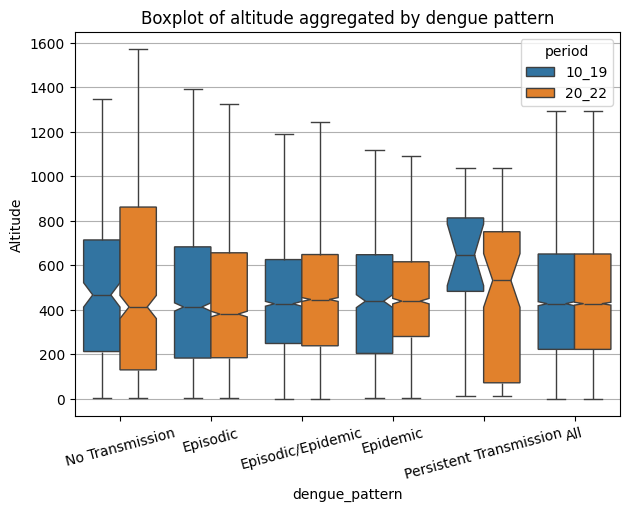

In [30]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='altitude', hue = 'period', data=df_det_, showfliers = False,  order = prof_order, ax=ax, notch = True)

sns.boxplot(y='altitude', hue = 'period', data=df_det_, showfliers = False,  ax=ax, notch = True, legend =  False)

ax.set_ylabel('Altitude')

ax.grid(True, axis='y')

ax.set_title('Boxplot of altitude aggregated by dengue pattern')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed
ax.set_xticklabels(list(prof_order) + ['All'])

plt.savefig('../figures/boxplot_alt.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/794347924.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/794347924.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_8303/794347924.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


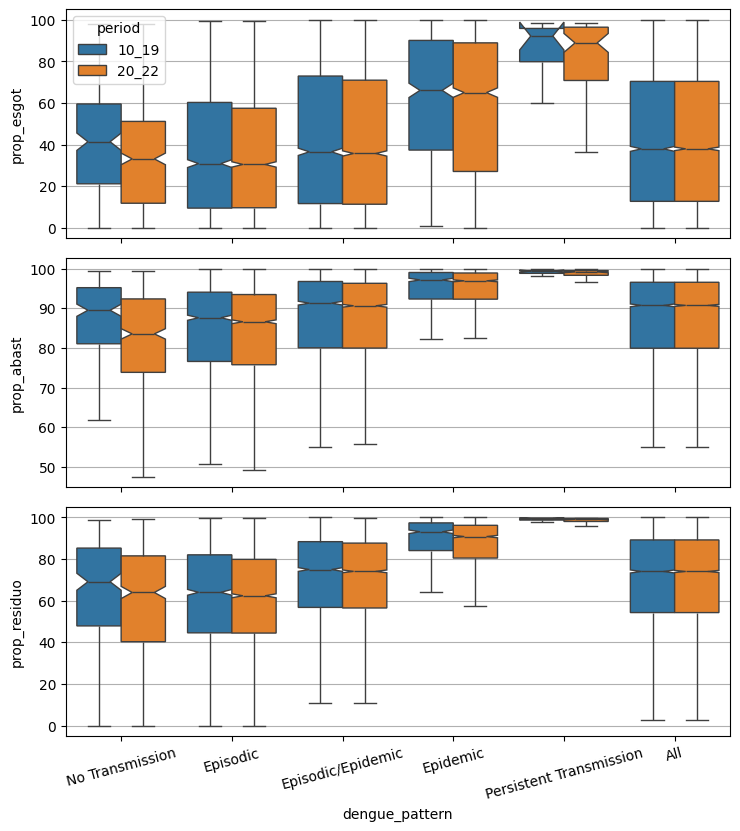

In [31]:
fig, ax = plt.subplots(3,1, figsize = (7.5,8), sharex = True)

sns.boxplot(x='dengue_pattern', y='prop_esgot', data=df_det_, hue = 'period', showfliers = False,  order = prof_order, ax=ax[0], notch = True,)

sns.boxplot(y='prop_esgot', hue = 'period', data=df_det_, showfliers = False,  ax=ax[0], notch = True, legend =  False)

#ax.set_ylabel('Altitude')

ax[0].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='prop_abast', data=df_det_, hue = 'period', showfliers = False,  order = prof_order, ax=ax[1], notch = True,
           legend = False)

sns.boxplot(y='prop_abast', hue = 'period', data=df_det_, showfliers = False,  ax=ax[1], notch = True, legend =  False)


ax[1].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='prop_residuo', data=df_det_, hue = 'period', showfliers = False,  order = prof_order, ax=ax[2], notch = True, 
           legend = False)

sns.boxplot(y='prop_residuo', hue = 'period', data=df_det_, showfliers = False,  ax=ax[2], notch = True, legend =  False)


ax[2].grid(True, axis='y')

#ax.set_title('Boxplot of altitude aggregated by dengue pattern')
for ax_ in ax.ravel():
    ax_.set_xticklabels(list(prof_order) + ['All'])
    
plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_ibge.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

## Repetindo os boxplots acima para os datasets de transição